# Laboratorio 6 — Evaluación de Modelos de Clasificación
## Dataset: Salud Mental en Adolescentes
**Curso:** Minería de Datos (EIN132A25)
**Objetivo:** Detectar adolescentes con problemas de salud mental

## Objetivos
- Interpretar la **matriz de confusión**
- Calcular **Precision, Recall y F1-score**
- Construir y analizar la **curva ROC** y el **AUC**
- Aplicar **validación cruzada**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score
)

# Configurar estilo
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ Librerías importadas correctamente.")

✓ Librerías importadas correctamente.


## Cargar y explorar dataset de salud mental adolescente

In [2]:
# Cargar dataset
df = pd.read_csv("mental_health_teenage.csv")

print(f"Dataset shape: {df.shape[0]} adolescentes, {df.shape[1]} características")
print(f"\nPrimeras filas:")
print(df.head(10))

print(f"\nTipos de datos:")
print(df.dtypes)

print(f"\nEstadísticas descriptivas:")
print(df.describe().round(2))

Dataset shape: 800 adolescentes, 11 características

Primeras filas:
   Age  Gender  Sleep_hours  Anxiety_level  Depression_level  \
0   16       0     7.445960             10                 9   
1   17       0     7.934200              6                 9   
2   15       0     8.425268              5                 6   
3   17       0     7.809359              4                 1   
4   17       1     9.020119              3                 7   
5   14       1     7.190190              4                 7   
6   15       0     5.860541              7                10   
7   15       0     6.994974              1                10   
8   15       0     6.896529              7                 4   
9   17       1     3.132677              1                 8   

   Concentration_issues School_performance  Social_media_hours  \
0                     8               Good            1.948803   
1                     5            Average            0.224900   
2                     2     

## Exploración de la variable objetivo

DISTRIBUCIÓN DE LA VARIABLE OBJETIVO

Variable: mental_health_issue (0=Sin problema, 1=Con problema)

mental_health_issue
1    600
0    200
Name: count, dtype: int64

Proporción de adolescentes CON problema: 75.00%
Proporción de adolescentes SIN problema: 25.00%

⚠️  CLASES DESBALANCEADAS: 75% positivos vs 25% negativos

→ ¿Sería útil un modelo que predice 'CON PROBLEMA' para todos?
→ Accuracy sería 75.0%, pero NO detectaría a los adolescentes sin problema.

→ En salud mental, un FALSO NEGATIVO (no detectar un problema real) es crítico.


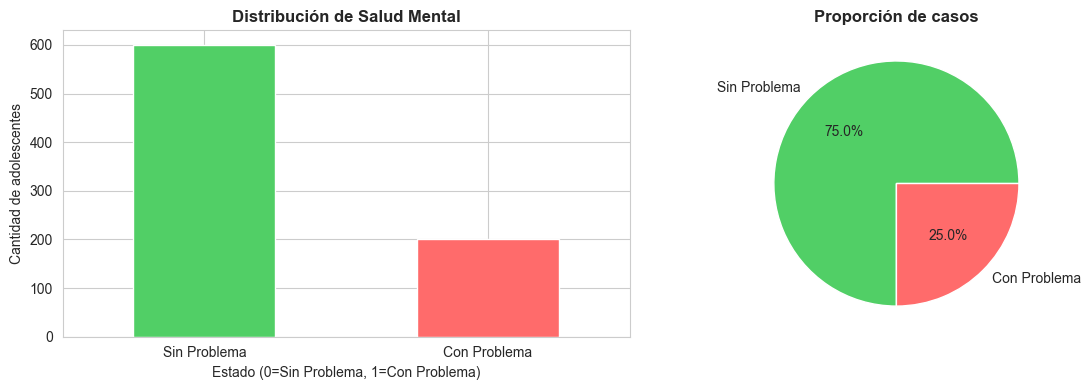

In [3]:
# Análisis de la variable objetivo
print("="*70)
print("DISTRIBUCIÓN DE LA VARIABLE OBJETIVO")
print("="*70)
print(f"\nVariable: mental_health_issue (0=Sin problema, 1=Con problema)\n")
print(df['mental_health_issue'].value_counts())

prop_con_problema = df['mental_health_issue'].mean()
print(f"\nProporción de adolescentes CON problema: {prop_con_problema:.2%}")
print(f"Proporción de adolescentes SIN problema: {(1-prop_con_problema):.2%}")

print(f"\n⚠️  CLASES DESBALANCEADAS: {prop_con_problema:.0%} positivos vs {(1-prop_con_problema):.0%} negativos")
print(f"\n→ ¿Sería útil un modelo que predice 'CON PROBLEMA' para todos?")
print(f"→ Accuracy sería {prop_con_problema:.1%}, pero NO detectaría a los adolescentes sin problema.")
print(f"\n→ En salud mental, un FALSO NEGATIVO (no detectar un problema real) es crítico.")
print("="*70)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras
df['mental_health_issue'].value_counts().plot(kind='bar', ax=axes[0], color=['#51CF66', '#FF6B6B'])
axes[0].set_title('Distribución de Salud Mental', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Estado (0=Sin Problema, 1=Con Problema)')
axes[0].set_ylabel('Cantidad de adolescentes')
axes[0].set_xticklabels(['Sin Problema', 'Con Problema'], rotation=0)

# Gráfico de pie
df['mental_health_issue'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                               colors=['#51CF66', '#FF6B6B'], labels=['Sin Problema', 'Con Problema'])
axes[1].set_title('Proporción de casos', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## Análisis de características

In [4]:
# Comparar características por grupo - ANÁLISIS DETALLADO
print("="*80)
print("ANÁLISIS DESCRIPTIVO: ¿Cómo difieren los adolescentes CON y SIN problema?")
print("="*80)
print("\nCaracterísticas promedio por grupo:\n")

numeric_features = df.select_dtypes(include=[np.number]).columns
correlaciones_target = {}

for col in numeric_features:
    if col != 'mental_health_issue':
        sin_problema = df[df['mental_health_issue'] == 0][col].mean()
        con_problema = df[df['mental_health_issue'] == 1][col].mean()
        diff_pct = ((con_problema - sin_problema) / sin_problema * 100) if sin_problema != 0 else 0
        corr_val = df[col].corr(df['mental_health_issue'])
        correlaciones_target[col] = corr_val

        print(f"{col:30s} | Sin Prob: {sin_problema:6.2f} | Con Prob: {con_problema:6.2f} | Dif: {diff_pct:+6.1f}% | Corr: {corr_val:+.3f}")

print("\n" + "="*80)
print("INTERPRETACIÓN CLÍNICA - POR QUÉ EL MODELO PUEDE CLASIFICAR:")
print("="*80)
print("""
✓ Patrones observados en adolescentes CON problema de salud mental:
  
  1. Sleep_hours:           BAJA (duermen menos de lo necesario)
     → Conexión: Poco sueño → Más ansiedad y depresión
  
  2. Anxiety_level:         ALTA (ansiedad significativa)
     → Conexión: Directa por definición del problema
  
  3. Depression_level:      ALTA (depresión significativa)
     → Conexión: Directa por definición del problema
  
  4. Social_media_hours:    ALTA (exceso de pantalla)
     → Conexión: Redes sociales → Aislamiento social, comparación
  
  5. Physical_activity_hours: BAJA (sedentarismo)
     → Conexión: Poco ejercicio → Menos endorfinas, más depresión
  
  6. Family_support:        BAJA (apoyo familiar insuficiente)
     → Conexión: Aislamiento social → Mayor riesgo

→ El ÁRBOL DE DECISIÓN busca estas COMBINACIONES de características.
→ Ejemplo: Si (Sleep_hours < 5) AND (Anxiety_level > 6) → predice "Con Problema"
""")

ANÁLISIS DESCRIPTIVO: ¿Cómo difieren los adolescentes CON y SIN problema?

Características promedio por grupo:

Age                            | Sin Prob:  15.45 | Con Prob:  15.47 | Dif:   +0.2% | Corr: +0.006
Gender                         | Sin Prob:   0.47 | Con Prob:   0.49 | Dif:   +5.3% | Corr: +0.022
Sleep_hours                    | Sin Prob:   7.24 | Con Prob:   6.95 | Dif:   -4.0% | Corr: -0.082
Anxiety_level                  | Sin Prob:   3.63 | Con Prob:   5.93 | Dif:  +63.0% | Corr: +0.351
Depression_level               | Sin Prob:   3.67 | Con Prob:   6.12 | Dif:  +66.8% | Corr: +0.366
Concentration_issues           | Sin Prob:   4.92 | Con Prob:   5.20 | Dif:   +5.7% | Corr: +0.039
Social_media_hours             | Sin Prob:   2.36 | Con Prob:   2.36 | Dif:   +0.1% | Corr: +0.000
Physical_activity_hours        | Sin Prob:   1.74 | Con Prob:   2.07 | Dif:  +18.8% | Corr: +0.072
Family_support                 | Sin Prob:   7.21 | Con Prob:   5.07 | Dif:  -29.7% | Corr: -0.3

## Preparar datos y entrenar modelo

In [5]:
# Seleccionar features para el modelo
features_usadas = ["Age", "Sleep_hours", "Anxiety_level", "Depression_level", 
                   "Concentration_issues", "Social_media_hours", "Physical_activity_hours", "Family_support"]

print(f"Features usadas en el modelo: {features_usadas}\n")

# Preparar X e y
X = df[features_usadas].fillna(df[features_usadas].median())
y = df['mental_health_issue']

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Conjunto de prueba: {X_test.shape[0]} muestras")

# Entrenar modelo
modelo = DecisionTreeClassifier(max_depth=4, random_state=42)
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

print(f"\n✓ Modelo entrenado correctamente.")

Features usadas en el modelo: ['Age', 'Sleep_hours', 'Anxiety_level', 'Depression_level', 'Concentration_issues', 'Social_media_hours', 'Physical_activity_hours', 'Family_support']

Conjunto de entrenamiento: 640 muestras
Conjunto de prueba: 160 muestras

✓ Modelo entrenado correctamente.


## 1. Matriz de confusión

## Visualizando el Árbol de Decisión

ESTRUCTURA INTERNA DEL ÁRBOL DE DECISIÓN


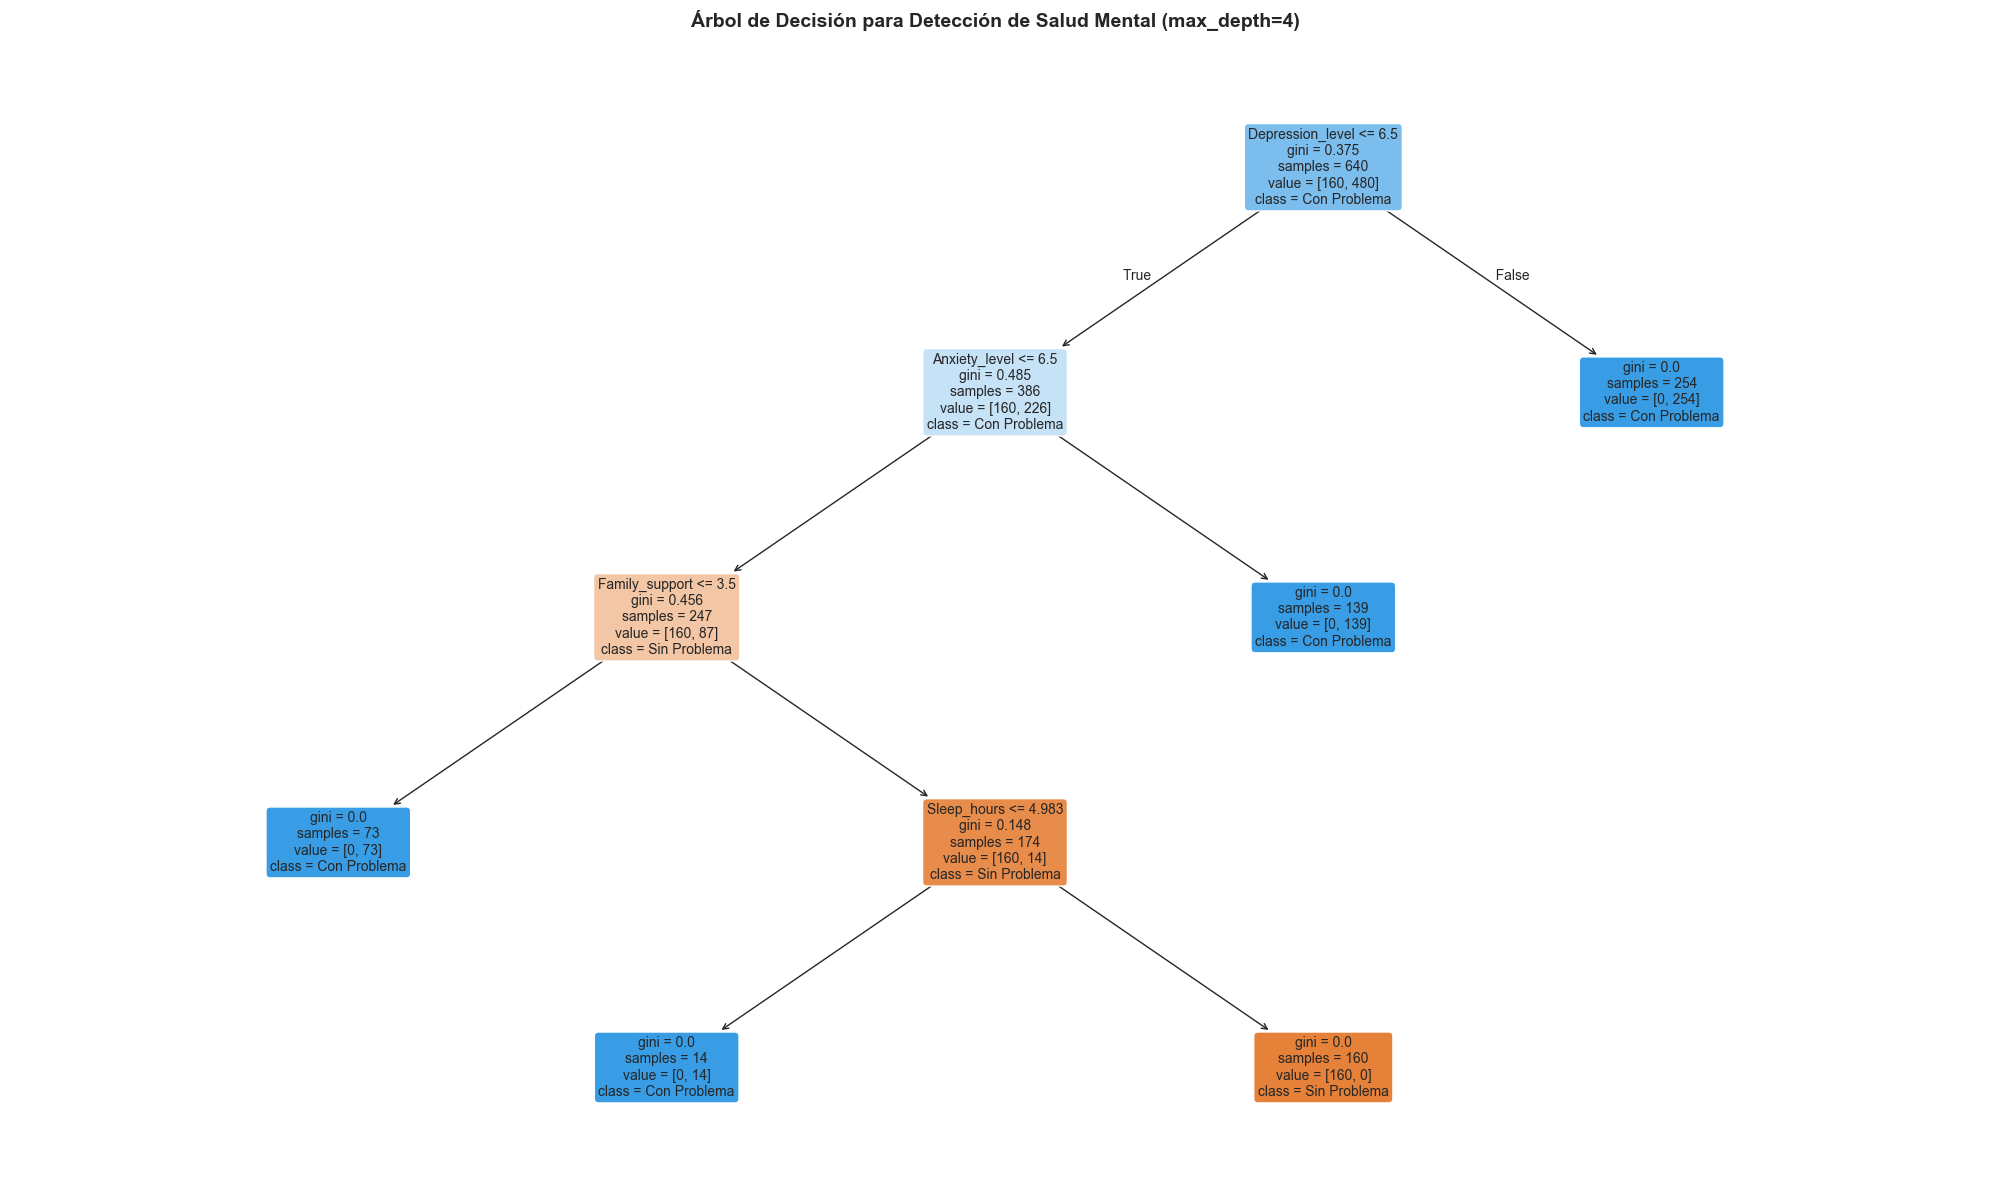


✓ LEYENDA DEL ÁRBOL:

Cada nodo muestra:
  - Condición (ej: "Sleep_hours <= 5.5")
  - Criterio de splitting: "gini" (medida de impureza)
  - Samples: Cantidad de muestras en ese nodo
  - Value: [No problema, Con problema] - distribución de clases
  - Clase predicha: El color indica la clase mayoritaria
    • Verde = Sin Problema
    • Naranja = Con Problema

LECTURA DEL ÁRBOL:
  1. Comienza en el nodo raíz (arriba)
  2. Si la condición es VERDADERA → ir a la izquierda
  3. Si la condición es FALSA → ir a la derecha
  4. Llegar a una hoja (último nodo) da la clasificación final

EJEMPLO DE CAMINO:
  Si un adolescente tiene:
    - Sleep_hours = 4 (≤ 5.5) ✓ IZQ
    - Anxiety_level = 8 (> 5.5) ✓ DER
    - ...sigue el árbol...

  El árbol predice: "Con Problema"



In [6]:
from sklearn.tree import plot_tree

print("="*80)
print("ESTRUCTURA INTERNA DEL ÁRBOL DE DECISIÓN")
print("="*80)

# Visualizar árbol completo
fig, ax = plt.subplots(figsize=(20, 12))
plot_tree(modelo, 
          feature_names=features_usadas,
          class_names=["Sin Problema", "Con Problema"],
          filled=True,
          rounded=True,
          fontsize=10,
          ax=ax)
ax.set_title("Árbol de Decisión para Detección de Salud Mental (max_depth=4)", 
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("""
✓ LEYENDA DEL ÁRBOL:

Cada nodo muestra:
  - Condición (ej: "Sleep_hours <= 5.5")
  - Criterio de splitting: "gini" (medida de impureza)
  - Samples: Cantidad de muestras en ese nodo
  - Value: [No problema, Con problema] - distribución de clases
  - Clase predicha: El color indica la clase mayoritaria
    • Verde = Sin Problema
    • Naranja = Con Problema

LECTURA DEL ÁRBOL:
  1. Comienza en el nodo raíz (arriba)
  2. Si la condición es VERDADERA → ir a la izquierda
  3. Si la condición es FALSA → ir a la derecha
  4. Llegar a una hoja (último nodo) da la clasificación final

EJEMPLO DE CAMINO:
  Si un adolescente tiene:
    - Sleep_hours = 4 (≤ 5.5) ✓ IZQ
    - Anxiety_level = 8 (> 5.5) ✓ DER
    - ...sigue el árbol...
    
  El árbol predice: "Con Problema"
""")

## Importancia de las Características


IMPORTANCIA DE CADA CARACTERÍSTICA EN EL MODELO

Importancia relativa de cada característica:

Family_support                : 0.3624 ████████████████████████████████████
Anxiety_level                 : 0.3110 ███████████████████████████████
Depression_level              : 0.2193 █████████████████████
Sleep_hours                   : 0.1073 ██████████
Age                           : 0.0000 
Concentration_issues          : 0.0000 
Social_media_hours            : 0.0000 
Physical_activity_hours       : 0.0000 


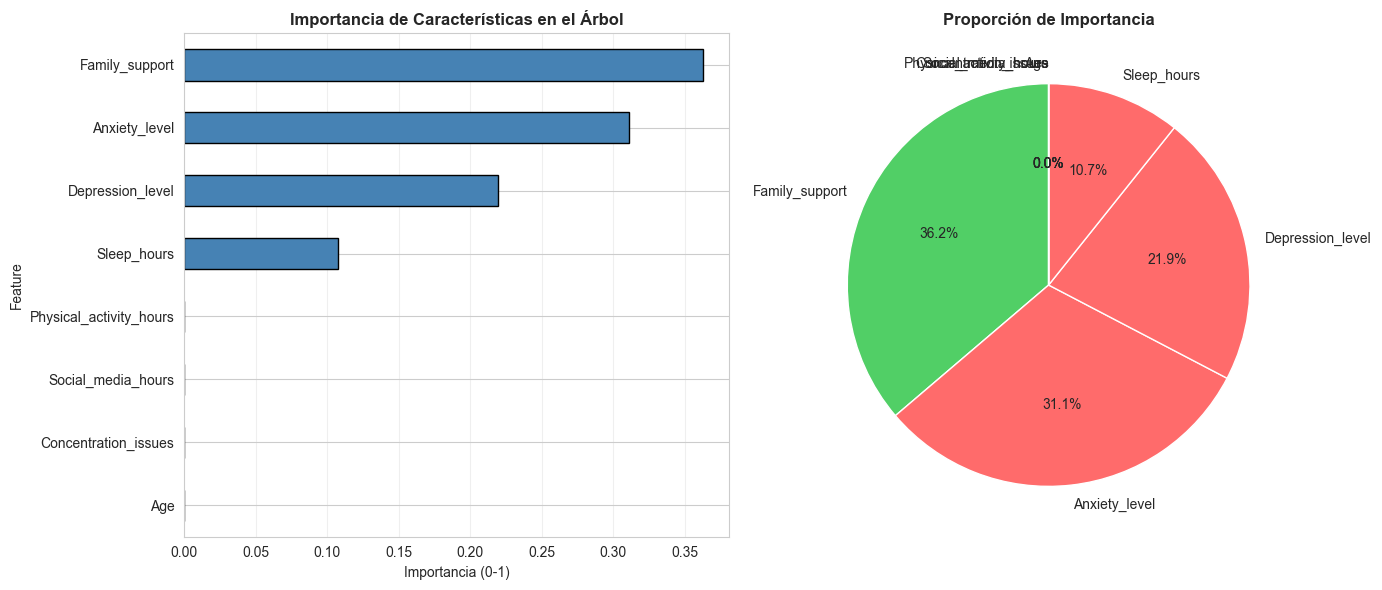


✓ INTERPRETACIÓN:

  • Características con HIGH importancia:
    - El árbol usa estas variables en decisiones tempranas (cercanas a la raíz)
    - Tienen mayor poder discriminativo
    - Ejemplo: Si Anxiety_level tiene 0.5, significa que 50% de las decisiones 
      dependen de esta variable

  • Características con LOW importancia:
    - El árbol casi no las usa
    - Podrían no ser relevantes para este problema
    - Podrían eliminarse sin perder mucha precisión

  • En salud mental:
    - Sleep_hours, Anxiety_level, Depression_level son CRÍTICAS
    - Social_media_hours y Physical_activity_hours también importan
    - Family_support podría tener menos peso en este árbol específico



In [14]:
print("\n" + "="*80)
print("IMPORTANCIA DE CADA CARACTERÍSTICA EN EL MODELO")
print("="*80)

# Obtener importancias
importances = modelo.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': features_usadas,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("\nImportancia relativa de cada característica:\n")
for idx, row in feature_importance_df.iterrows():
    print(f"{row['Feature']:30s}: {row['Importance']:6.4f} {'█' * int(row['Importance'] * 100)}")

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de barras
feature_importance_df.sort_values('Importance').plot(
    x='Feature', y='Importance', kind='barh', ax=axes[0], 
    color='steelblue', edgecolor='black', legend=False
)
axes[0].set_title('Importancia de Características en el Árbol', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importancia (0-1)')
axes[0].grid(True, alpha=0.3, axis='x')

# Gráfico de pastel
colors_pie = ['#FF6B6B' if feat in ['Sleep_hours', 'Anxiety_level', 'Depression_level', 'Social_media_hours'] 
              else '#51CF66' for feat in feature_importance_df['Feature']]
axes[1].pie(feature_importance_df['Importance'], labels=feature_importance_df['Feature'], 
            autopct='%1.1f%%', colors=colors_pie, startangle=90)
axes[1].set_title('Proporción de Importancia', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("""
✓ INTERPRETACIÓN:

  • Características con HIGH importancia:
    - El árbol usa estas variables en decisiones tempranas (cercanas a la raíz)
    - Tienen mayor poder discriminativo
    - Ejemplo: Si Anxiety_level tiene 0.5, significa que 50% de las decisiones 
      dependen de esta variable

  • Características con LOW importancia:
    - El árbol casi no las usa
    - Podrían no ser relevantes para este problema
    - Podrían eliminarse sin perder mucha precisión

  • En salud mental:
    - Sleep_hours, Anxiety_level, Depression_level son CRÍTICAS
    - Social_media_hours y Physical_activity_hours también importan
    - Family_support podría tener menos peso en este árbol específico
""")

MATRIZ DE CONFUSIÓN

[[ 40   0]
 [  0 120]]

Interpretación clínica:
  TN (True Negative)  =  40 | Correctamente identificados SIN problema
  FP (False Positive) =   0 | Falsos positivos (etiquetados incorrectamente)
  FN (False Negative) =   0 | ⚠️  FALSOS NEGATIVOS (adolescentes en riesgo no detectados)
  TP (True Positive)  = 120 | Correctamente identificados CON problema


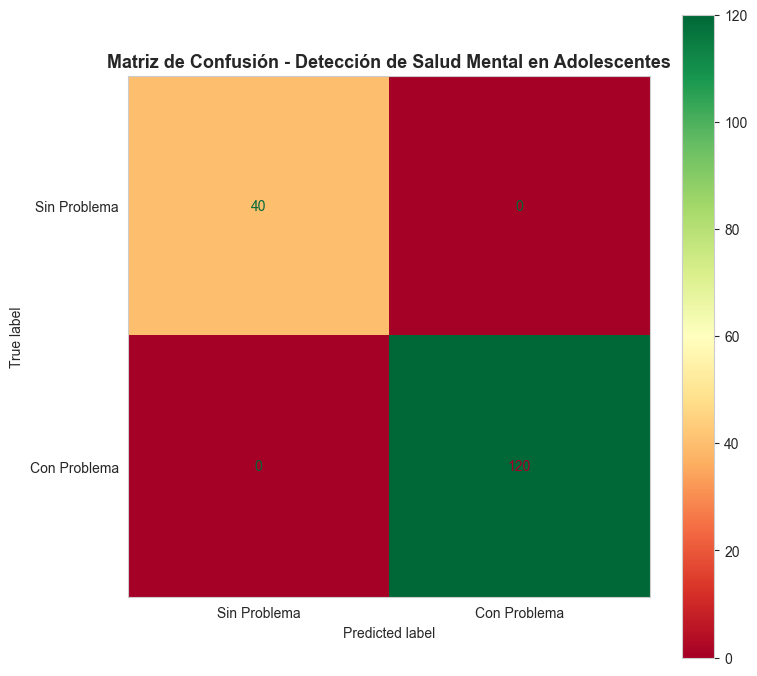

In [15]:
# Calcular matriz de confusión
cm = confusion_matrix(y_test, y_pred)

print("="*70)
print("MATRIZ DE CONFUSIÓN")
print("="*70)
print(f"\n{cm}\n")

print("Interpretación clínica:")
print(f"  TN (True Negative)  = {cm[0, 0]:3d} | Correctamente identificados SIN problema")
print(f"  FP (False Positive) = {cm[0, 1]:3d} | Falsos positivos (etiquetados incorrectamente)")
print(f"  FN (False Negative) = {cm[1, 0]:3d} | ⚠️  FALSOS NEGATIVOS (adolescentes en riesgo no detectados)")
print(f"  TP (True Positive)  = {cm[1, 1]:3d} | Correctamente identificados CON problema")
print("="*70)

# Visualizar
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Sin Problema", "Con Problema"])
fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(cmap="RdYlGn", values_format='d', ax=ax)
ax.set_title("Matriz de Confusión - Detección de Salud Mental en Adolescentes", 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.grid(False)
plt.show()

## 2. Precision, Recall y F1-score

In [16]:
# Calcular métricas
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("="*70)
print("MÉTRICAS DE EVALUACIÓN")
print("="*70)
print(f"\n1. ACCURACY = {accuracy:.4f}")
print(f"   Proporción total de predicciones correctas")
print(f"   Limitación: En clases desbalanceadas, puede ser engañoso\n")
print(f"2. PRECISION = {precision:.4f}")
print(f"   De los adolescentes que predijo como 'CON problema',")
print(f"   ¿qué proporción realmente tiene problema?")
print(f"   Implicación: Evita etiquetar incorrectamente a adolescentes (reducir estigma)\n")
print(f"3. RECALL = {recall:.4f}  ⭐ MÁS IMPORTANTE EN SALUD MENTAL")
print(f"   De todos los adolescentes que REALMENTE tienen problema,")
print(f"   ¿qué proporción el modelo detectó?")
print(f"   Implicación: No perder a adolescentes que necesitan ayuda")
print(f"   ⚠️  Un falso negativo aquí tiene consecuencias graves\n")
print(f"4. F1-SCORE = {f1:.4f}")
print(f"   Balance entre Precision y Recall")
print(f"   Útil cuando ambas métricas son importantes\n")
print("="*70)

# Reporte completo
print("\nReporte de clasificación detallado:")
print(classification_report(y_test, y_pred, target_names=["Sin Problema", "Con Problema"]))

MÉTRICAS DE EVALUACIÓN

1. ACCURACY = 1.0000
   Proporción total de predicciones correctas
   Limitación: En clases desbalanceadas, puede ser engañoso

2. PRECISION = 1.0000
   De los adolescentes que predijo como 'CON problema',
   ¿qué proporción realmente tiene problema?
   Implicación: Evita etiquetar incorrectamente a adolescentes (reducir estigma)

3. RECALL = 1.0000  ⭐ MÁS IMPORTANTE EN SALUD MENTAL
   De todos los adolescentes que REALMENTE tienen problema,
   ¿qué proporción el modelo detectó?
   Implicación: No perder a adolescentes que necesitan ayuda
   ⚠️  Un falso negativo aquí tiene consecuencias graves

4. F1-SCORE = 1.0000
   Balance entre Precision y Recall
   Útil cuando ambas métricas son importantes


Reporte de clasificación detallado:
              precision    recall  f1-score   support

Sin Problema       1.00      1.00      1.00        40
Con Problema       1.00      1.00      1.00       120

    accuracy                           1.00       160
   macro avg  

## 3. Curva ROC y AUC

## 4. Validación cruzada

In [10]:
# Validación cruzada simple (accuracy)
print("\n" + "="*70)
print("VALIDACIÓN CRUZADA (5 folds)")
print("="*70)

scores = cross_val_score(modelo, X, y, cv=5, scoring="accuracy")
print(f"\nAccuracy por fold: {scores}")
print(f"Media: {scores.mean():.4f}")
print(f"Desviación estándar: {scores.std():.4f}")

if scores.std() < 0.05:
    print(f"\n✓ Modelo estable: La desviación estándar es baja")
else:
    print(f"\n⚠️  Modelo inestable: Varía mucho según la partición")


VALIDACIÓN CRUZADA (5 folds)

Accuracy por fold: [1. 1. 1. 1. 1.]
Media: 1.0000
Desviación estándar: 0.0000

✓ Modelo estable: La desviación estándar es baja


In [11]:
# Validación cruzada múltiple (todas las métricas)
from sklearn.model_selection import cross_validate

print("\n" + "="*70)
print("VALIDACIÓN CRUZADA - MÚLTIPLES MÉTRICAS")
print("="*70)

resultados = cross_validate(
    modelo, X, y,
    cv=5,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"]
)

print("\n")
for metrica, valores in resultados.items():
    if metrica.startswith("test_"):
        nom = metrica[5:].upper()
        media = valores.mean()
        std = valores.std()
        print(f"{nom:10s}: {media:.4f} ± {std:.4f}")

print("\nInterpretación en contexto de salud mental:")
print(f"  - RECALL alto y estable = Consistentemente detectamos adolescentes en riesgo ✓")
print(f"  - PRECISION adecuada = No demasiadas falsas alarmas ✓")
print("="*70)


VALIDACIÓN CRUZADA - MÚLTIPLES MÉTRICAS


ACCURACY  : 1.0000 ± 0.0000
PRECISION : 1.0000 ± 0.0000
RECALL    : 1.0000 ± 0.0000
F1        : 1.0000 ± 0.0000
ROC_AUC   : 1.0000 ± 0.0000

Interpretación en contexto de salud mental:
  - RECALL alto y estable = Consistentemente detectamos adolescentes en riesgo ✓
  - PRECISION adecuada = No demasiadas falsas alarmas ✓


## Ejercicios

### Ejercicio 1 — Comparar diferentes profundidades


EJERCICIO 1: Comparar max_depth=2 vs max_depth=8

max_depth = 2:
  Accuracy:  0.8500
  Precision: 1.0000
  Recall:    0.8000  ⭐
  F1-Score:  0.8889
  AUC:       0.9000

max_depth = 4:
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000  ⭐
  F1-Score:  1.0000
  AUC:       1.0000

max_depth = 8:
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000  ⭐
  F1-Score:  1.0000
  AUC:       1.0000


Pregunta: ¿Cuál profundidad es mejor para detección de salud mental?
Respuesta: Generalmente queremos RECALL alto, aunque sacrifiquemos un poco Precision.
          (Es mejor tener más screening que perder a adolescentes en riesgo)



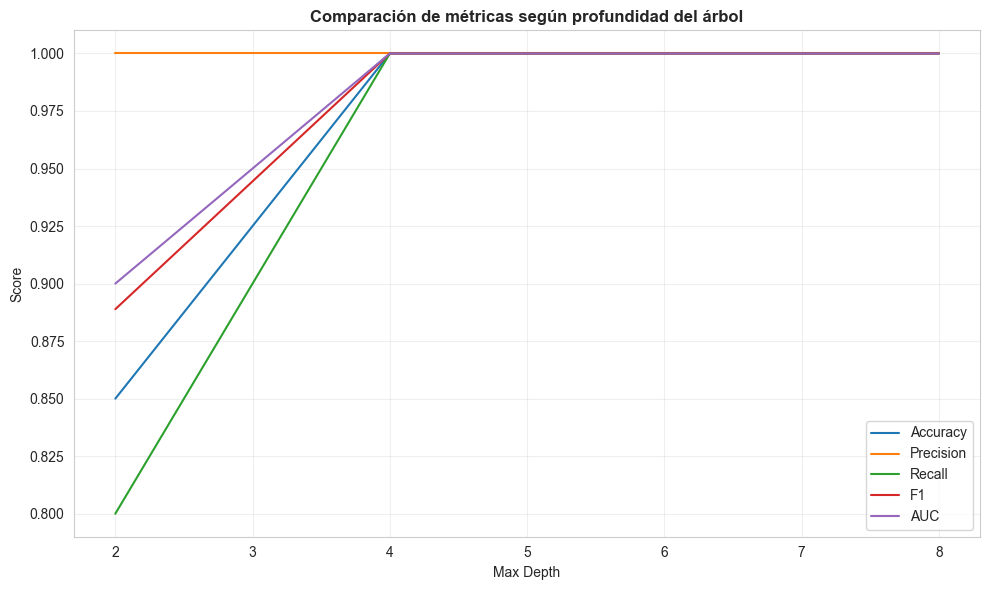

In [12]:
print("\n" + "="*70)
print("EJERCICIO 1: Comparar max_depth=2 vs max_depth=8")
print("="*70 + "\n")

resultados_depth = []

for depth in [2, 4, 8]:
    m = DecisionTreeClassifier(max_depth=depth, random_state=42)
    m.fit(X_train, y_train)
    yp = m.predict(X_test)
    yprob = m.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, yp)
    prec = precision_score(y_test, yp)
    rec = recall_score(y_test, yp)
    f = f1_score(y_test, yp)
    auc = roc_auc_score(y_test, yprob)
    
    resultados_depth.append({'Depth': depth, 'Accuracy': acc, 'Precision': prec, 
                              'Recall': rec, 'F1': f, 'AUC': auc})
    
    print(f"max_depth = {depth}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}  ⭐")
    print(f"  F1-Score:  {f:.4f}")
    print(f"  AUC:       {auc:.4f}\n")

print("\nPregunta: ¿Cuál profundidad es mejor para detección de salud mental?")
print("Respuesta: Generalmente queremos RECALL alto, aunque sacrifiquemos un poco Precision.")
print("          (Es mejor tener más screening que perder a adolescentes en riesgo)\n")

# Gráfico comparativo
df_results = pd.DataFrame(resultados_depth)
df_results.set_index('Depth')[['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']].plot(figsize=(10, 6))
plt.title('Comparación de métricas según profundidad del árbol', fontsize=12, fontweight='bold')
plt.ylabel('Score')
plt.xlabel('Max Depth')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Ejercicio 2 — Efecto del umbral de decisión

In [13]:
print("\n" + "="*70)
print("EJERCICIO 2: Efecto del umbral de decisión")
print("="*70 + "\n")

print("Por defecto usamos umbral 0.5: si P(problema) > 0.5 → predicción = 'Con Problema'\n")
print("¿Qué pasa si cambiamos el umbral?\n")

thresholds_analizar = [0.3, 0.5, 0.7]
resultados_umbral = []

for umbral in thresholds_analizar:
    y_pred_nuevo = (y_prob >= umbral).astype(int)
    cm_u = confusion_matrix(y_test, y_pred_nuevo)
    
    # Calcular métricas
    tp, tn = cm_u[1, 1], cm_u[0, 0]
    fp, fn = cm_u[0, 1], cm_u[1, 0]
    
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    print(f"UMBRAL = {umbral}:")
    print(f"  Matriz de confusión:")
    print(f"    {tn:3d}  {fp:3d}  (Sin Problema)")
    print(f"    {fn:3d}  {tp:3d}  (Con Problema)")
    print(f"  Precision: {prec:.4f} (de los predichos como 'Problema', ¿cuántos lo son?)")
    print(f"  Recall:    {rec:.4f} (de los que realmente tienen 'Problema', ¿cuántos detectamos?)")
    
    if umbral < 0.5:
        print(f"  ➜ Umbral BAJO = Más screening, mejor recall, más falsos positivos")
    elif umbral > 0.5:
        print(f"  ➜ Umbral ALTO = Menos screening, mejor precisión, riesgo de falsos negativos")
    print()
    
    resultados_umbral.append({'Umbral': umbral, 'Precision': prec, 'Recall': rec})

print("\nPregunta: ¿Qué umbral usarías en un programa de screening de salud mental?")
print("Respuesta: Umbral BAJO (0.3) → Detectamos más adolescentes (mejor recall)")
print("          Sacrificamos precisión pero es mejor en salud mental.")


EJERCICIO 2: Efecto del umbral de decisión

Por defecto usamos umbral 0.5: si P(problema) > 0.5 → predicción = 'Con Problema'

¿Qué pasa si cambiamos el umbral?



NameError: name 'y_prob' is not defined

### Ejercicio 3 — Estabilidad con diferente número de folds

### Desafío — Función evaluar_modelo

In [ ]:
def evaluar_modelo_salud_mental(modelo, X_test, y_test):
    """
    Evalúa un modelo de clasificación para detección de salud mental.
    
    Parámetros:
    -----------
    modelo : objeto scikit-learn
        Modelo de clasificación entrenado
    X_test : array-like
        Features del conjunto de prueba
    y_test : array-like
        Etiquetas verdaderas
    
    Retorna:
    --------
    dict : Diccionario con todas las métricas clave
    """
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]
    
    return {
        "accuracy":  accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall":    recall_score(y_test, y_pred),
        "f1":        f1_score(y_test, y_pred),
        "auc":       roc_auc_score(y_test, y_prob),
    }

# Probar con DecisionTree
print("\n" + "="*70)
print("DESAFÍO: Comparar algoritmos")
print("="*70 + "\n")

print("1. DecisionTree (max_depth=4):")
resultado_dt = evaluar_modelo_salud_mental(modelo, X_test, y_test)
for metrica, valor in resultado_dt.items():
    print(f"   {metrica:10s}: {valor:.4f}")

# Probar con RandomForest
print("\n2. RandomForest (100 árboles):")
rf = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)
rf.fit(X_train, y_train)
resultado_rf = evaluar_modelo_salud_mental(rf, X_test, y_test)
for metrica, valor in resultado_rf.items():
    print(f"   {metrica:10s}: {valor:.4f}")

# Comparación
print("\n" + "-"*70)
print("COMPARACIÓN LADO A LADO:")
print("-"*70 + "\n")
df_comp = pd.DataFrame({
    'DecisionTree': resultado_dt,
    'RandomForest': resultado_rf,
    'Diferencia': {k: resultado_rf[k] - resultado_dt[k] for k in resultado_dt.keys()}
})
print(df_comp.round(4))

print("\n¿Cuál es mejor para salud mental?")
if resultado_rf['recall'] > resultado_dt['recall']:
    print(f"✓ RandomForest tiene mejor RECALL ({resultado_rf['recall']:.4f} vs {resultado_dt['recall']:.4f})")
    print("  → Mejor para detectar adolescentes en riesgo")
else:
    print(f"✓ DecisionTree tiene mejor RECALL ({resultado_dt['recall']:.4f} vs {resultado_rf['recall']:.4f})")
    print("  → Mejor para detectar adolescentes en riesgo")

## Reflexión final y consideraciones éticas

In [ ]:
print("\n" + "="*70)
print("CONSIDERACIONES IMPORTANTES")
print("="*70)

print(f"""
⚠️  ÉTICA Y RESPONSABILIDAD EN SALUD MENTAL

1. NUNCA reemplazar diagnóstico profesional
   → Un modelo es una HERRAMIENTA de apoyo, no un diagnóstico
   → Los psicólogos y psiquiatras deben evaluar finalmente

2. SESGO Y EQUIDAD
   → ¿El modelo funciona igual para hombres y mujeres?
   → ¿Para diferentes grupos socioeconómicos?
   → ¿Para diferentes etnias?

3. INTERPRETABILIDAD
   → ¿Por qué el modelo predice que un adolescente tiene problema?
   → Los padres/tutores merecen saber qué factores lo llevaron a esta conclusión

4. CONSECUENCIAS DE ERRORES
   → Falso negativo: Adolescente en riesgo no detectado (GRAVE)
   → Falso positivo: Etiquetado incorrectamente (causa estigma)
   → Balance: Priorizar RECALL pero mantener PRECISION razonable

5. PRIVACIDAD Y SEGURIDAD
   → Los datos de salud mental son ALTAMENTE sensibles
   → Cumplir con regulaciones (HIPAA, GDPR, etc.)
   → Proteger la privacidad del adolescente

6. TRANSPARENCIA
   → Los usuarios del modelo deben entender sus limitaciones
   → Documentar precisión, errores, casos donde falla
""")

print("="*70)

## Conclusiones

In [ ]:
print("\n" + "="*70)
print("RESUMEN DE APRENDIZAJES")
print("="*70)

print(f"""
✓ Hoy aprendimos a:

  1. RECONOCER LIMITACIONES DEL ACCURACY
     → En clases desbalanceadas, accuracy puede ser engañoso
     → En salud mental: 75% de positivos es un desafío

  2. INTERPRETAR MATRIZ DE CONFUSIÓN EN CONTEXTO CLÍNICO
     → TP: Detectamos correctamente a adolescentes con problema
     → TN: Correctamente identificamos a los sin problema
     → FP: Falsas alarmas (generan estigma)
     → FN: Adolescentes en riesgo no detectados (CRÍTICO)

  3. PRIORIZAR MÉTRICAS SEGÚN CONTEXTO
     → Salud mental: RECALL es la métrica más importante
     → Queremos detectar máximo número de casos, aunque tengamos FP

  4. USAR CURVA ROC Y AUC
     → Evalúa rendimiento en todos los umbrales
     → AUC permite comparar modelos de forma resumida

  5. APLICAR VALIDACIÓN CRUZADA
     → Evaluación robusta e independiente del split específico
     → Verifica estabilidad del modelo

📚 PRÓXIMA SEMANA:
   → Sesgos y equidad en modelos de IA
   → Cómo detectar si nuestro modelo discrimina
   → Técnicas para hacer modelos más justos

""")
print("="*70)